In [2]:
%load_ext autoreload
%autoreload 2

In [8]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from scipy.stats import linregress
from RaTag.core.fitting import fit_gaussian_to_histogram, plot_gaussian_fit
%matplotlib inline

In [2]:
768* 4

3072

# Collection efficiency measurements

# Temporal rough analysis (while data taking)

## Run0: measuring positive ions

First successful run, but measuring positive current (positive ions)

[Text(0.5, 0, 'Cathode Voltage (V)'),
 Text(0, 0.5, 'Gate Current (pA)'),
 Text(0.5, 1.0, 'Collection efficiency')]

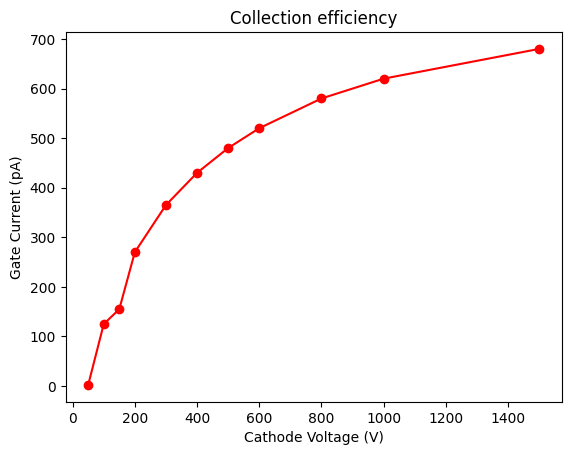

In [ ]:
V = np.array([50, 100, 150, 200, 300, 400, 500, 600, 800, 1000, 1500])
I = np.array([2.2, 125, 155, 270, 365, 430, 480, 520, 580, 620, 680])
slope, intercept, r_value, p_value, std_err = linregress(V, I)
x_int = np.arange(50, 800, 1)
plt.plot(V, I, 'ro-')
# plt.plot(x_int, [slope*x + intercept for x in x_int], 'b--')
plt.gca().set(xlabel='Cathode Voltage (V)', ylabel='Gate Current (pA)', title='Collection efficiency')

## Collection efficiency: Run2 and Run7

Measuring the current in the gate (ground) while changing the the cathode voltage (drift field)
- Electrometer (GND) - Gate
- PS CAEN 1470, Ch0 (negative) drift voltage - Cathode = variable
- PS Tennelec - Anode:  set to -200 V (run2) and -1000 V (run7)

The objective is comparing if different EL fields affect the collection efficiency. 
There is very little difference between the two curves, so not really

[Text(0.5, 0, 'Cathode Voltage (V)'),
 Text(0, 0.5, 'Gate Current (pA)'),
 Text(0.5, 1.0, 'Collection efficiency')]

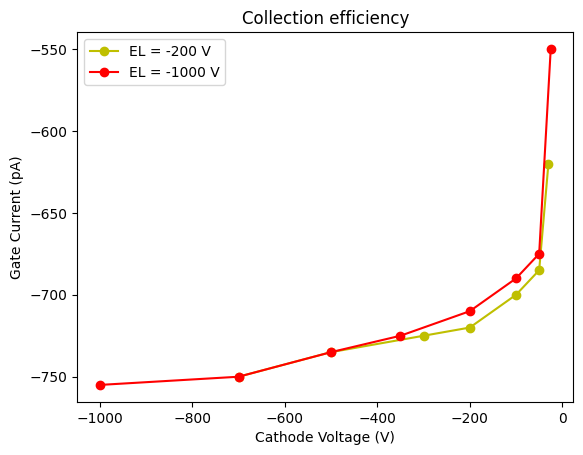

In [4]:
V = np.array([-30, -50, -100, -200, -300, -500, -700])
I = np.array([-620, -685, -700, -720, -725, -735, -750])
plt.plot(V, I, 'yo-', label='EL = -200 V')

V2 = np.array([-25,-50, -100, -200, -350, -500, -700, -1000])
I2 = np.array([-550, -675, -690, -710, -725, -735, -750, -755])
slope, intercept, r_value, p_value, std_err = linregress(V, I)
x_int = np.arange(50, 800, 1)
plt.plot(V2, I2, 'ro-', label='EL = -1000 V')
plt.legend()
# plt.plot(x_int, [slope*x + intercept for x in x_int], 'b--')
plt.gca().set(xlabel='Cathode Voltage (V)', ylabel='Gate Current (pA)', title='Collection efficiency')

## Braking efficiency curves

Fixing the cathode voltage (drift field) we increase the braking potential in the anode to check at which value all the electrons are successfully extracted (gate current drops to zero)

Then we repeat this for different drift field values.
- Run3: V_cathode = -200 V
- Run8: V_cathode = -100 V
- Run9: V_cathode = -500 V
- Run10: V_cathode = -50 V
- Run11: V_cathode = -300 V

[Text(0.5, 0, 'Anode Voltage (V)'),
 Text(0, 0.5, 'Gate Current (pA)'),
 Text(0.5, 1.0, 'Braking efficiency')]

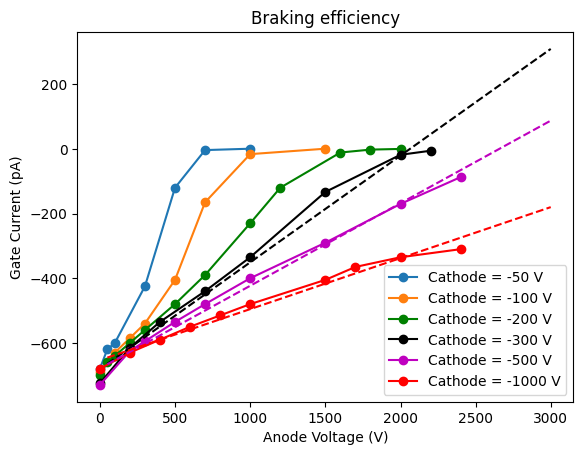

In [143]:
V0 = np.array([   0,   50,  100,  300,  500, 700, 1000])
I0 = np.array([-680, -620, -600, -425, -120, -3.5, 0.8])

V1 = np.array([   0,  100,  200,  300,  500,  700, 1000, 1500])
I1 = np.array([-690, -630, -585, -540, -405, -165,  -16,  0.8])

V2 = np.array([   0,  50,  100,  200,  300,  500,  700, 1000, 1200, 1600, 1800, 2000])
I2 = np.array([-700, -660, -640, -600, -560, -480, -390, -230, -120,  -11,   -2,  0.1])

V3 = np.array([   0,  200,  400,  700, 1000, 1500, 2000, 2200])
I3 = np.array([-725, -615, -535, -440, -335, -133,  -18, -5.5])

V4 = np.array([   0,  200,  300,  500,  700, 1000, 1500, 2000, 2400])
I4 = np.array([-730, -625, -595, -535, -480, -400,  -290, -170, -87])

V10 = np.array([   0,  200,  400,  600,  800, 1000, 1500, 1700, 2000, 2400])
I10 = np.array([-680, -630, -590, -550, -515, -480, -405, -365, -335, -310])

slope3, intercept3, r_value, p_value, std_err = linregress(V3, I3)
slope4, intercept4, r_value, p_value, std_err = linregress(V4, I4)
slope10, intercept10, r_value, p_value, std_err = linregress(V10, I10)
x_int = np.arange(50, 3000, 1)

plt.plot(V0, I0, 'o-', label ='Cathode = -50 V')
plt.plot(V1, I1, 'o-', label='Cathode = -100 V')
plt.plot(V2, I2, 'go-', label='Cathode = -200 V')
line3 = plt.plot(V3, I3, 'ko-', label='Cathode = -300 V')[0]
line4 = plt.plot(V4, I4, 'mo-', label='Cathode = -500 V')[0]
line10 = plt.plot(V10, I10, 'ro-', label='Cathode = -1000 V')[0]
plt.plot(x_int, [slope3*x + intercept3 for x in x_int], '--' , color=line3.get_color())
plt.plot(x_int, [slope4*x + intercept4 for x in x_int], '--' , color=line4.get_color())
plt.plot(x_int, [slope10*x + intercept10 for x in x_int], '--' , color=line10.get_color())
plt.legend()
plt.gca().set(xlabel='Anode Voltage (V)', ylabel='Gate Current (pA)', title='Braking efficiency')

# Fits to logistic and ERF functions

In [79]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit

def logistic_current(Va, I0, V50, dV):
    """
    Gate current vs anode voltage.
    I0  : plateau current magnitude (pA)
    V50 : braking voltage at 50% transmission (V)
    dV  : transition width (V)
    """
    return I0 / (1.0 + np.exp((Va - V50) / dV))


def erf_current(Va, I0, V50, sigma):
    return 0.5 * I0 * (1.0 - erf((Va - V50) / (np.sqrt(2) * sigma)))

def residuals(model, popt, Va, I):
    return I - model(Va, *popt)

def AIC(residuals, k):
    rss = np.sum(residuals**2)
    return rss + 2*k

def eta_logistic(Va, V50, dV):
    return 1.0 / (1.0 + np.exp((Va - V50) / dV))

In [87]:
def fit_collection_efficiency(Va, I):

    I = np.abs(I)

    # Initial guesses
    I0_guess = np.max(I)
    V50_guess = Va[np.argmin(np.abs(I - 0.5 * I0_guess))]
    dV_guess = 200.0

    p0_log = [I0_guess, V50_guess, dV_guess]
    bounds_log = ([0, 0, 10], [np.inf, 5000, 2000])

    popt_log, pcov_log = curve_fit(
        logistic_current,
        Va, I,
        p0=p0_log,
        bounds=bounds_log
    )

    sigma_guess = 300.0
    p0_erf = [I0_guess, V50_guess, sigma_guess]
    bounds_erf = ([0, 0, 10], [np.inf, 5000, 3000])

    popt_erf, pcov_erf = curve_fit(
        erf_current,
        Va, I,
        p0=p0_erf,
        bounds=bounds_erf
    )

    res_log = residuals(logistic_current, popt_log, Va, I)
    res_erf = residuals(erf_current, popt_erf, Va, I)
    return (popt_log, res_log), (popt_erf, res_erf)

In [93]:
V0 = np.array([   0,   50,  100,  300,  500, 700, 1000])
I0 = np.array([-680, -620, -600, -425, -120, -3.5, 0.8])

V1 = np.array([   0,  100,  200,  300,  500,  700, 1000, 1500])
I1 = np.array([-690, -630, -585, -540, -405, -165,  -16,  0.8])

V2 = np.array([   0,  50,  100,  200,  300,  500,  700, 1000, 1200, 1600, 1800, 2000])
I2 = np.array([-700, -660, -640, -600, -560, -480, -390, -230, -120,  -11,   -2,  0.1])

V3 = np.array([   0,  200,  400,  700, 1000, 1500, 2000, 2200])
I3 = np.array([-725, -615, -535, -440, -335, -133,  -18, -5.5])

V4 = np.array([   0,  200,  300,  500,  700, 1000, 1500, 2000, 2400])
I4 = np.array([-730, -625, -595, -535, -480, -400,  -290, -170, -87])

V10 = np.array([   0,  200,  400,  600,  800, 1000, 1500, 1700, 2000, 2400])
I10 = np.array([-680, -630, -590, -550, -515, -480, -405, -365, -335, -310])

I0 = np.abs(I0)
I1 = np.abs(I1)
I2 = np.abs(I2)
I3 = np.abs(I3)
I4 = np.abs(I4)
I10 = np.abs(I10)

In [94]:
(plog0, rlog0), (perf0, rerf0) = fit_collection_efficiency(V0, I0)
(plog1, rlog1), (perf1, rerf1) = fit_collection_efficiency(V1, I1)
(plog2, rlog2), (perf2, rerf2) = fit_collection_efficiency(V2, I2)
(plog3, rlog3), (perf3, rerf3) = fit_collection_efficiency(V3, I3)
(plog4, rlog4), (perf4, rerf4) = fit_collection_efficiency(V4, I4)
(plog10, rlog10), (perf10, rerf10) = fit_collection_efficiency(V10, I10)

Text(0, 0.5, 'Gate current (pA)')

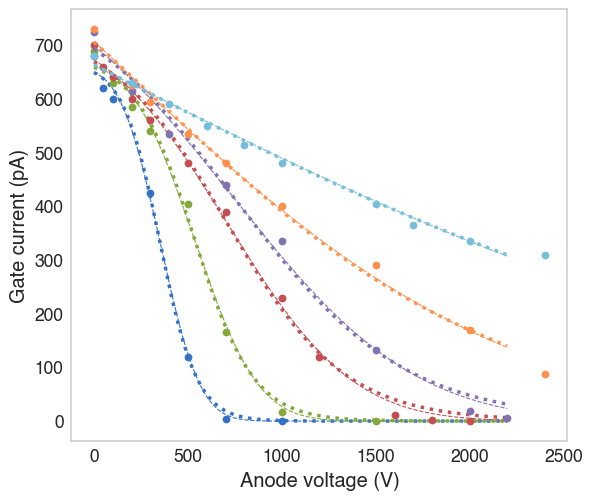

In [95]:
x_int = np.arange(0, 2200, 1)
for V, I in [(V0, I0), (V1, I1), (V2, I2), (V3, I3), (V4, I4), (V10, I10)]:
    line = plt.plot(V, I, 'o')[0]
    (plog, rlog), (perf, rerf) = fit_collection_efficiency(V, I)
    
    plt.plot(x_int, logistic_current(x_int, *plog), ':', lw=2.5, color=line.get_color(), label='Logistic fit')
    plt.plot(x_int, erf_current(x_int, *perf), '--', lw=0.8, color=line.get_color(), label='Erf fit')
plt.xlabel("Anode voltage (V)")
plt.ylabel("Gate current (pA)")

In [91]:
def transm_eff(I_meas):
    i0 = np.abs(I_meas[0])
    return 1.0 - I_meas / i0

Text(0, 0.5, 'Transmission efficiency')

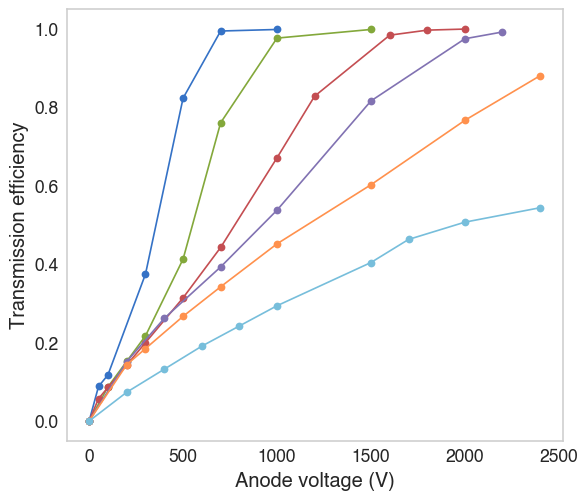

In [98]:
T0 = transm_eff(I0)
T1 = transm_eff(I1)
T2 = transm_eff(I2)
T3 = transm_eff(I3)
T4 = transm_eff(I4)
T10 = transm_eff(I10)
for T, V in [(T0, V0), (T1, V1), (T2, V2), (T3, V3), (T4, V4), (T10, V10)]:
    plt.plot(V, T, 'o-')
plt.xlabel("Anode voltage (V)")
plt.ylabel("Transmission efficiency")

In [106]:
2000 / 0.8

2500.0

Text(0.5, 1.0, 'Transmission efficiency vs drift field at E_EL = 2500 V/cm')

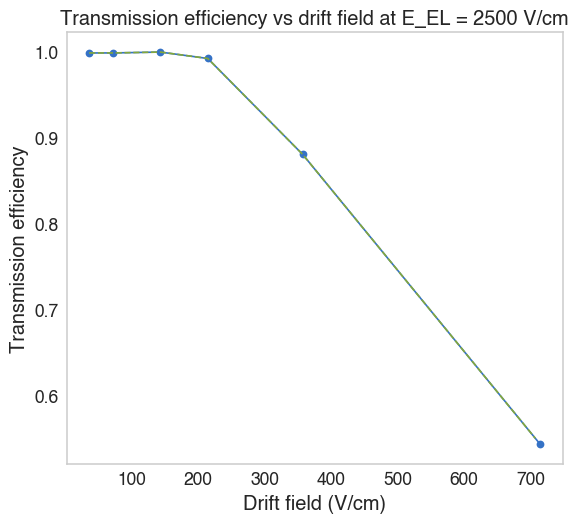

In [107]:
E_d = np.array([50, 100, 200, 300, 500, 1000])/1.4
# T = np.array([0.99882353, 0.99884058, 0.99985714, 0.99241379, 0.88082192, 0.54411765])
T = np.array([T0[-1], T1[-1], T2[-1], T3[-1], T4[-1], T10[-1]])
E_interp = np.arange(50, 1000, 10)/1.4
T_interp = np.interp(E_interp, E_d, T)
plt.plot(E_d, T, 'o-')
plt.plot(E_interp, T_interp, '--')
plt.xlabel("Drift field (V/cm)")
plt.ylabel("Transmission efficiency")
plt.title("Transmission efficiency vs drift field at E_EL = 2500 V/cm")

In [105]:
T

array([0.99882353, 0.99884058, 0.99985714, 0.99241379, 0.88082192,
       0.54411765])

/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_25946/2382515727.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[Text(0.5, 0, 'Anode Voltage (V)'),
 Text(0, 0.5, 'Residual (pA)'),
 Text(0.5, 1.0, 'Collection efficiency residuals')]

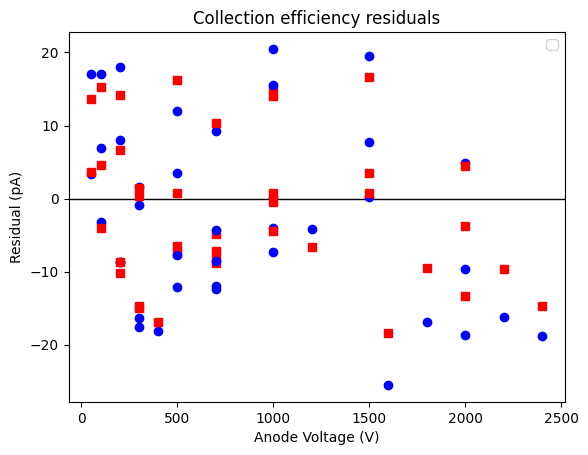

In [131]:
plt.axhline(0, color='k', lw=1)
x_int = np.arange(0, 2200, 1)
for V, I in [(V0, I0), (V1, I1), (V2, I2), (V3, I3), (V4, I4)]:
    (plog, rlog), (perf, rerf) = fit_collection_efficiency(V, I)
    
    plt.plot(V, rlog, 'ob', label='__nolabel__')
    plt.plot(V, rerf, 'sr', label='__nolabel__')

    plt.legend()
plt.gca().set(xlabel='Anode Voltage (V)', ylabel='Residual (pA)', title='Collection efficiency residuals')

In [132]:
I0_log = []
I0_erf = []
V50_log = []
dV_log = []
V50_erf = []
sigma_erf = []
eta_logs = []
E_drift = np.array([50, 100, 200, 300, 500])/ 1.4 # V/cm
for V, I in [(V0, I0), (V1, I1), (V2, I2), (V3, I3), (V4, I4)]:
    (plog, rlog), (perf, rerf) = fit_collection_efficiency(V, I)
    I0_log.append(plog[0])
    I0_erf.append(perf[0])
    V50_log.append(plog[1])
    dV_log.append(plog[2])
    V50_erf.append(perf[1])
    sigma_erf.append(perf[2])
    AIC_log = AIC(rlog, k=3)
    AIC_erf = AIC(rerf, k=3)
    eta_logs.append(eta_logistic(V, plog[1], plog[2]))
    print(f"AIC Logistic: {AIC_log:.2f}, AIC Erf: {AIC_erf:.2f}")

AIC Logistic: 181.75, AIC Erf: 61.28
AIC Logistic: 854.07, AIC Erf: 899.03
AIC Logistic: 2429.15, AIC Erf: 1390.03
AIC Logistic: 1729.28, AIC Erf: 1042.19
AIC Logistic: 981.00, AIC Erf: 679.08


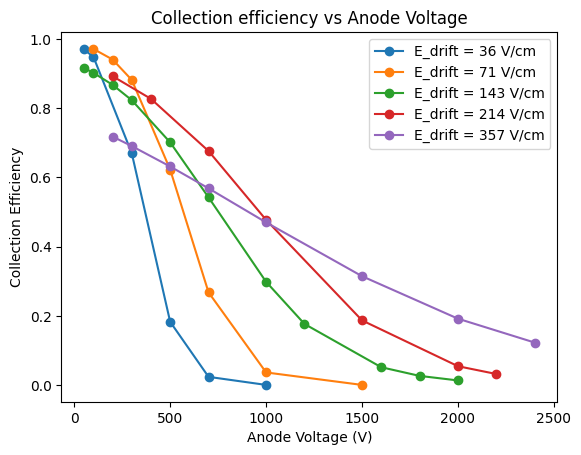

In [133]:
for i, (V, I) in enumerate([(V0, I0), (V1, I1), (V2, I2), (V3, I3), (V4, I4)]):
    (plog, rlog), (perf, rerf) = fit_collection_efficiency(V, I)

    eta = eta_logistic(V, plog[1], plog[2], )
    plt.plot(V, eta, 'o-', label=f'E_drift = {E_drift[i]:.0f} V/cm')
plt.gca().set(xlabel='Anode Voltage (V)', ylabel='Collection Efficiency', title='Collection efficiency vs Anode Voltage')
plt.legend()

In [134]:
from scipy.interpolate import interp1d

V50_of_Ed = interp1d(E_drift, V50_log,
                     kind='linear', fill_value='extrapolate')

dV_of_Ed  = interp1d(E_drift, dV_log,
                     kind='linear', fill_value='extrapolate')

In [135]:
EL_gap_cm = 0.8
def eta_2D(E_drift, E_EL):
    V50 = V50_of_Ed(E_drift)
    dV  = dV_of_Ed(E_drift)
    Va  = E_EL * EL_gap_cm
    return 1.0 - 1.0 / (1.0 + np.exp((Va - V50) / dV))

[Text(0.5, 0, 'Drift field (V/cm)'),
 Text(0, 0.5, 'EL field (kV/cm)'),
 Text(0.5, 1.0, 'Gate → EL transmission efficiency')]

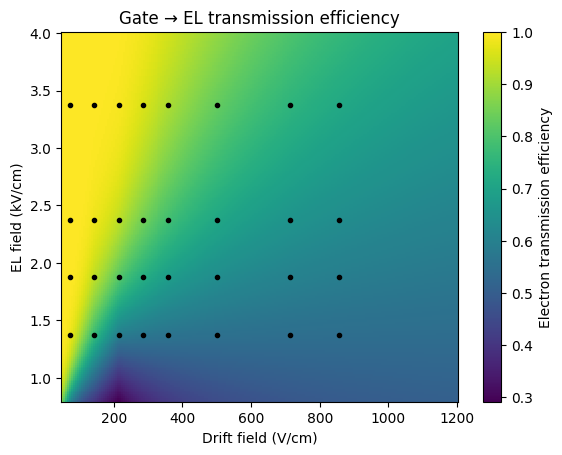

In [136]:
E_drift_vals = np.linspace(50, 1200, 200)    # V/cm
E_EL_vals    = np.linspace(800, 4.0e3, 200)  # V/cm

E_drift_grid, E_EL_grid = np.meshgrid(E_drift_vals, E_EL_vals)

eta_grid = eta_2D(E_drift_grid, E_EL_grid)

# The real runs
E_EL_runs = [1.375e3, 1.875e3, 2.375e3, 3.375e3]   # V/cm
E_drift_runs = np.array([100, 200, 300, 400, 500, 700, 1000, 1200]) / 1.4

pcm = plt.pcolormesh( E_drift_grid, E_EL_grid / 1e3,
                     eta_grid, shading='auto', cmap='viridis')
# for E_EL in E_EL_runs:
#     plt.plot(E_drift_runs, np.full_like(E_drift_runs, E_EL/1e3),
#              'w--', lw=1)
    
for E_EL in E_EL_runs:
    for E_d in E_drift_runs:
        plt.plot(E_d, E_EL/1e3, 'ko', ms=3)

cbar = plt.colorbar(pcm)
cbar.set_label("Electron transmission efficiency")
plt.gca().set(xlabel='Drift field (V/cm)', ylabel='EL field (kV/cm)', title='Gate → EL transmission efficiency')

In [113]:
pathout = '/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency'
np.savez_compressed(f"{pathout}/eta_surface.npz",
                    E_drift_vals=E_drift_vals,
                    E_EL_vals=E_EL_vals,
                    eta_grid=eta_grid)
print(f"Saved eta surface -> {pathout}/eta_surface.npz")


Saved eta surface -> /Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/eta_surface.npz


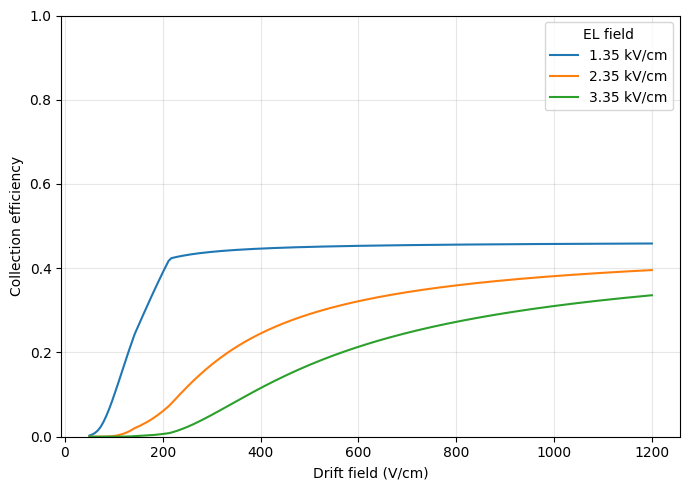

In [98]:
plt.figure(figsize=(7,5))

for E_EL in E_EL_runs:
    eta_slice = eta_2D(E_drift_vals, E_EL)
    plt.plot(E_drift_vals, eta_slice, label=f"{E_EL/1e3:.2f} kV/cm")

plt.xlabel("Drift field (V/cm)")
plt.ylabel("Collection efficiency")
plt.ylim(0, 1.0)
plt.legend(title="EL field")
plt.grid(alpha=0.3)

plt.tight_layout()


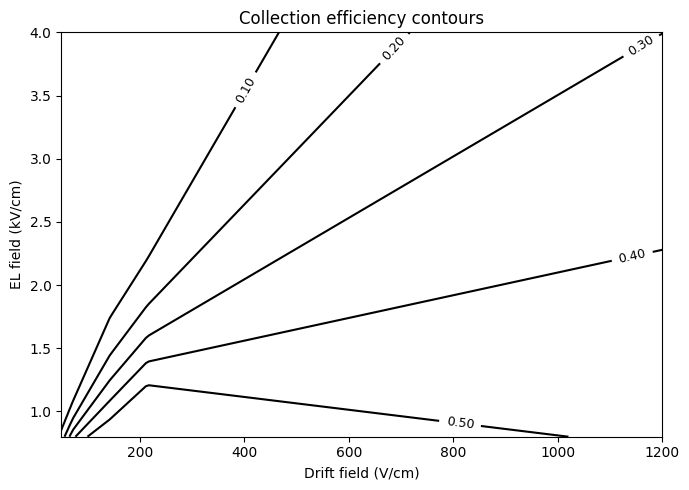

In [ ]:
plt.figure(figsize=(7,5))

cs = plt.contour(E_drift_grid,
                 E_EL_grid/1e3,
                 eta_grid,
    levels=[0.1, 0.2, 0.3, 0.4, 0.5 ],
    colors='k')

plt.clabel(cs, inline=True, fontsize=9, fmt="%.2f")

plt.xlabel("Drift field (V/cm)")
plt.ylabel("EL field (kV/cm)")
plt.title("Collection efficiency contours")

plt.tight_layout()

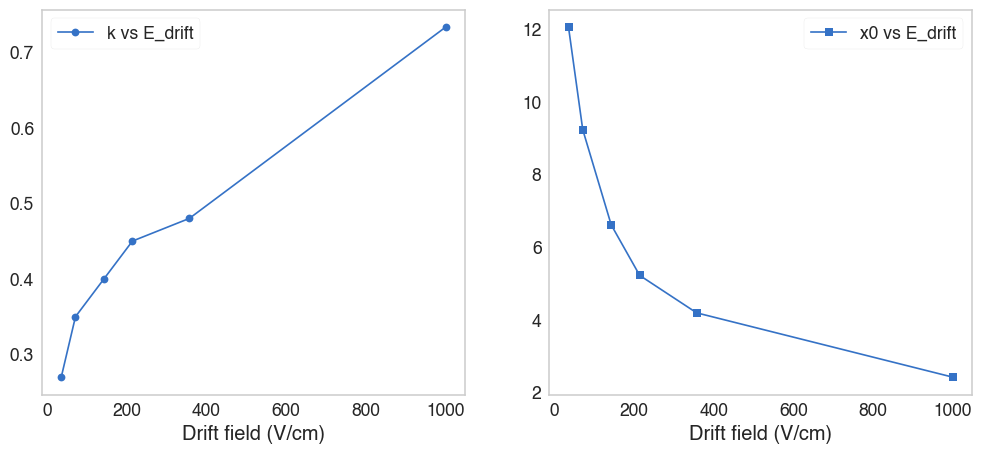

In [180]:
ed_anchors = np.array([35.71, 71.43, 142.86, 214.29, 357.14, 1000.0])
k_anchors  = np.array([0.27, 0.35, 0.40, 0.45, 0.48, 0.733])
x0_anchors = np.array([12.05, 9.23, 6.61, 5.22, 4.19, 2.42])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(ed_anchors, k_anchors, 'o-', label='k vs E_drift')
ax[1].plot(ed_anchors, x0_anchors, 's-', label='x0 vs E_drift')
ax[0].set_xlabel("Drift field (V/cm)")
ax[1].set_xlabel("Drift field (V/cm)")
ax[0].legend()
ax[1].legend()

### 3D surface plot

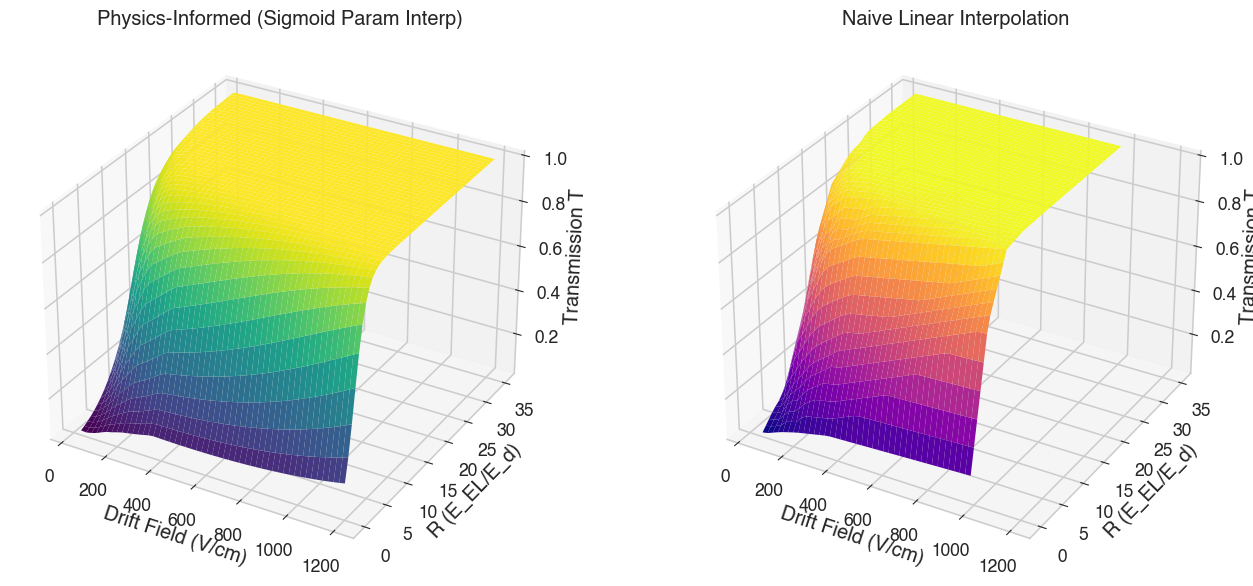

In [179]:
from scipy.interpolate import interp1d, griddata
from mpl_toolkits.mplot3d import Axes3D

# 1. Anchor data for Sigmoid Parameter Interpolation
ed_anchors = np.array([35.71, 71.43, 142.86, 214.29, 357.14, 1000.0])
k_anchors  = np.array([0.27, 0.35, 0.40, 0.45, 0.48, 0.733])
x0_anchors = np.array([12.05, 9.23, 6.61, 5.22, 4.19, 2.42])

# Parameter Interpolators
get_k = interp1d(ed_anchors, k_anchors, kind='linear', fill_value='extrapolate')
get_x0 = interp1d(ed_anchors, x0_anchors, kind='linear', fill_value='extrapolate')

def get_t_sigmoid(E_d, R):
    """Reconstructs T based on interpolated sigmoid parameters."""
    k = get_k(E_d)
    x0 = get_x0(E_d)
    return 1 / (1 + np.exp(-k * (R - x0)))

# 2. Define the grid for the 3D Plot
ed_range = np.linspace(35, 1200, 50)
r_range = np.linspace(0, 35, 50)
ED, R = np.meshgrid(ed_range, r_range)

# Calculate Physics-Informed T
T_sigmoid = np.clip(get_t_sigmoid(ED, R), 0, 1)

# 3. Create a Naive Linear Interpolation for comparison
# Generating dummy "raw" data points based on your measured curves
raw_points = []
raw_values = []
for ed, k, x0 in zip(ed_anchors, k_anchors, x0_anchors):
    r_samples = np.linspace(0, 35, 10)
    for rs in r_samples:
        t_val = 1 / (1 + np.exp(-k * (rs - x0)))
        raw_points.append([ed, rs])
        raw_values.append(t_val)

T_naive = griddata(np.array(raw_points), np.array(raw_values), (ED, R), method='linear')

# 4. Plotting
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(ED, R, T_sigmoid, cmap='viridis', edgecolor='none')
ax1.set_title('Physics-Informed (Sigmoid Param Interp)')
ax1.set_xlabel('Drift Field (V/cm)'); ax1.set_ylabel('R (E_EL/E_d)'); ax1.set_zlabel('Transmission T')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(ED, R, T_naive, cmap='plasma', edgecolor='none')
ax2.set_title('Naive Linear Interpolation')
ax2.set_xlabel('Drift Field (V/cm)'); ax2.set_ylabel('R (E_EL/E_d)'); ax2.set_zlabel('Transmission T')

plt.show()

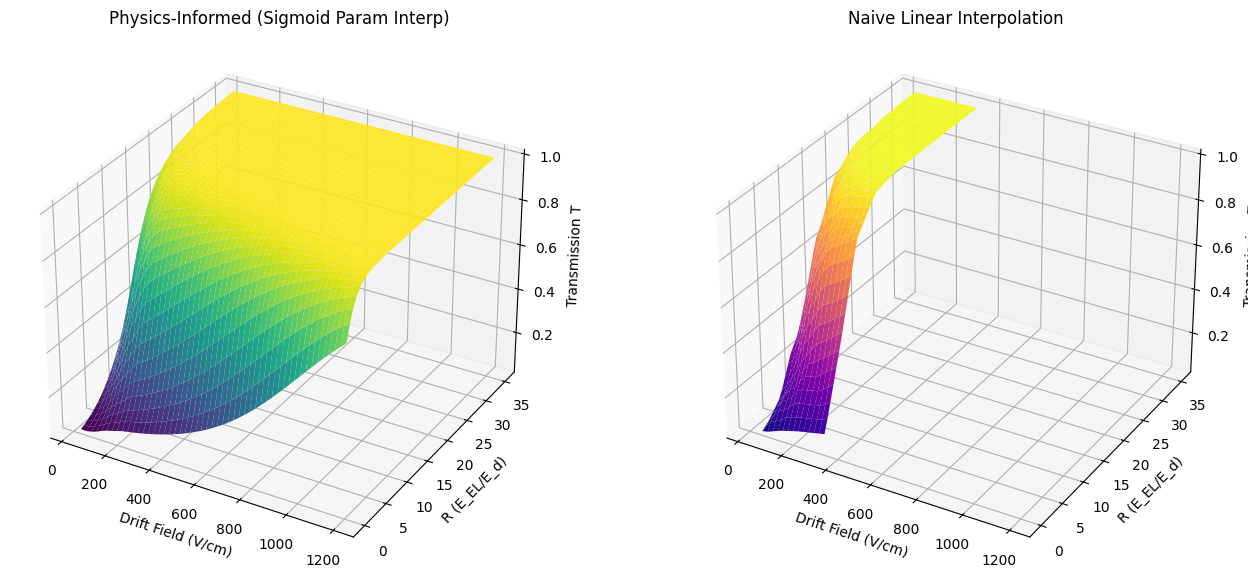

In [ ]:
from scipy.interpolate import interp1d, griddata
from mpl_toolkits.mplot3d import Axes3D

# 1. Anchor data for Sigmoid Parameter Interpolation
ed_anchors = np.array([35.71, 71.43, 142.86, 214.29, 357.14, 1000.0])
k_anchors  = np.array([0.27, 0.35, 0.40, 0.45, 0.48, 0.733])
x0_anchors = np.array([12.05, 9.23, 6.61, 5.22, 4.19, 2.42])

# Parameter Interpolators
get_k = interp1d(ed_anchors, k_anchors, kind='linear', fill_value='extrapolate')
get_x0 = interp1d(ed_anchors, x0_anchors, kind='linear', fill_value='extrapolate')

def get_t_sigmoid(E_d, R):
    """Reconstructs T based on interpolated sigmoid parameters."""
    k = get_k(E_d)
    x0 = get_x0(E_d)
    return 1 / (1 + np.exp(-k * (R - x0)))

# 2. Define the grid for the 3D Plot
ed_range = np.linspace(35, 1200, 50)
r_range = np.linspace(0, 35, 50)
ED, R = np.meshgrid(ed_range, r_range)

# Calculate Physics-Informed T
T_sigmoid = np.clip(get_t_sigmoid(ED, R), 0, 1)

# 3. Create a Naive Linear Interpolation for comparison
# Generating dummy "raw" data points based on your measured curves
raw_points = []
raw_values = []
for ed, k, x0 in zip(ed_anchors, k_anchors, x0_anchors):
    r_samples = np.linspace(0, 35, 10)
    for rs in r_samples:
        t_val = 1 / (1 + np.exp(-k * (rs - x0)))
        raw_points.append([ed, rs])
        raw_values.append(t_val)

T_naive = griddata(np.array(raw_points), np.array(raw_values), (ED, R), method='linear')

# 4. Plotting
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(ED, R, T_sigmoid, cmap='viridis', edgecolor='none')
ax1.set_title('Physics-Informed (Sigmoid Param Interp)')
ax1.set_xlabel('Drift Field (V/cm)'); ax1.set_ylabel('R (E_EL/E_d)'); ax1.set_zlabel('Transmission T')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(ED, R, T_naive, cmap='plasma', edgecolor='none')
ax2.set_title('Naive Linear Interpolation')
ax2.set_xlabel('Drift Field (V/cm)'); ax2.set_ylabel('R (E_EL/E_d)'); ax2.set_zlabel('Transmission T')

plt.show()

# Transmission efficiency (Run14)

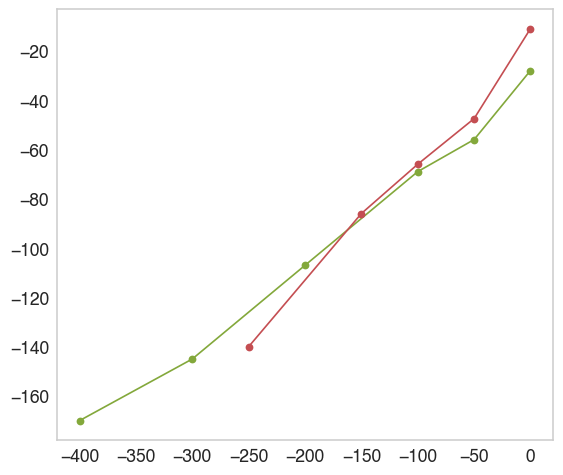

In [115]:
V5 = np.array([ -400,  -300, -200, -100, -50,  0  ])
I5 = np.array([ -170,  -145,  -107, -69, -56, -28 ])

V3 = np.array([ -250, -150, -100, -50,   0 ])
I3 = np.array([ -140,  -86, -66,  -47.5, -11])
plt.plot(V5, I5, 'go-', label='Cathode = -500 V')
plt.plot(V3, I3, 'ro-', label='Cathode = -300 V')

In [113]:
def compute_R_field(V_anode, V_cathode, V_gate, gap_drift, gap_el):
    E_drift = (V_gate - V_cathode) / gap_drift
    E_EL = (V_anode - V_gate) / gap_el
    return E_EL / E_drift

[Text(0.5, 0, 'EL field / Drift field'),
 Text(0, 0.5, 'Gate Transmission Efficiency'),
 Text(0.5, 1.0, 'Gate Transmission efficiency vs EL/Drift field ratio')]

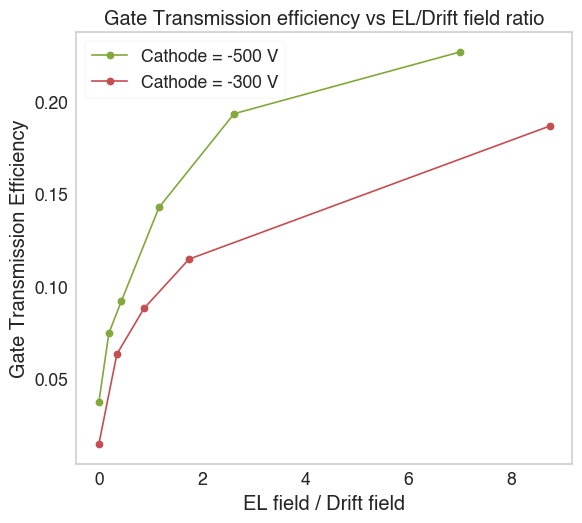

In [116]:
gap_el_cm = 0.8
gap_drift_cm = 1.4
V_anode = 0

Isat5 = -750
T5 = I5 / Isat5
R_field5 = compute_R_field(V_anode, -500, V5, gap_drift_cm, gap_el_cm)

Isat3 = -750
T3 = I3 / Isat3
R_field3 = compute_R_field(V_anode, -300, V3, gap_drift_cm, gap_el_cm)

plt.plot(R_field5, T5, 'go-', label='Cathode = -500 V')
plt.plot(R_field3, T3, 'ro-', label='Cathode = -300 V')
plt.legend()
plt.gca().set(xlabel='EL field / Drift field', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs EL/Drift field ratio')


# Transmission efficiency for fixed field ratio

[Text(0.5, 0, 'Drift field (V/cm)'),
 Text(0, 0.5, 'Anode current (pA)'),
 Text(0.5, 1.0, 'Anode current vs EL/Drift field ratio')]

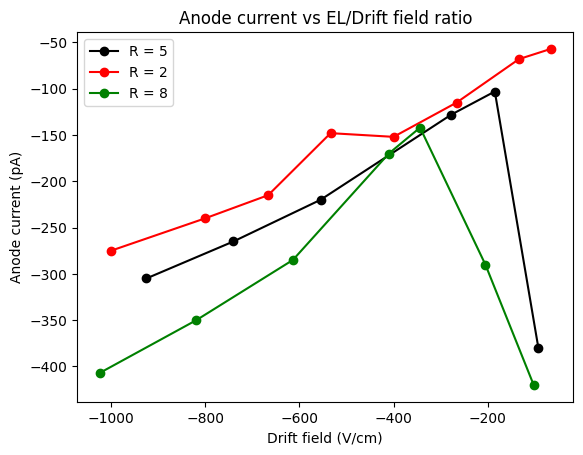

In [ ]:
V_cath0 = np.array([-100, -200, -400, -600, -800, -1000])
V_gate0 = np.array([ -74, -148, -222, -444, -592, -740])
I_anode0 = np.array([-380, -103, -128, -220, -265, -305])

V_cath1 = np.array([-100, -200, -400, -600, -800, -1000, -1200, -1500])
V_gate1 = np.array([ -53, -107, -213, -320, -427,  -533,  -640,  -800])
I_anode1 = np.array([-57,  -68, -115, -152, -148,  -215,  -240,  -275])

V_cath2 = np.array([ -100, -200, -300, -400, -600, -800, -1000, ])
V_gate2 = np.array([  -82, -164, -275, -328, -491, -655, -819, ])
I_anode2 = np.array([-420, -290, -142, -170, -285, -350, -407])


R_field = compute_R_field(0, V_cath0, V_gate0, gap_drift_cm, gap_el_cm)
# plt.plot(R_field, I_anode0, 'ko-', label='Anode current')
plt.plot(V_gate0 / gap_el_cm, I_anode0, 'ko-', label='R = 5')
plt.plot(V_gate1 / gap_el_cm, I_anode1, 'ro-', label='R = 2')
plt.plot(V_gate2 / gap_el_cm, I_anode2, 'go-', label='R = 8')
plt.legend()
plt.gca().set(xlabel='Drift field (V/cm)', ylabel='Anode current (pA)', title='Anode current vs EL/Drift field ratio')

In [107]:
300 * 0.819

245.7

# Numerical values for Transmission efficiency:

$$ T(E_{EL}) = 1 - \frac{I_{\mathrm{gate}} (V_{\mathrm{anode}}) }{I_{\mathrm{gate}} (V_{\mathrm{anode}} = 0)}

[Text(0.5, 0, 'Anode Voltage (V)'),
 Text(0, 0.5, 'Gate Transmission Efficiency'),
 Text(0.5, 1.0, 'Gate Transmission efficiency vs Anode Voltage')]

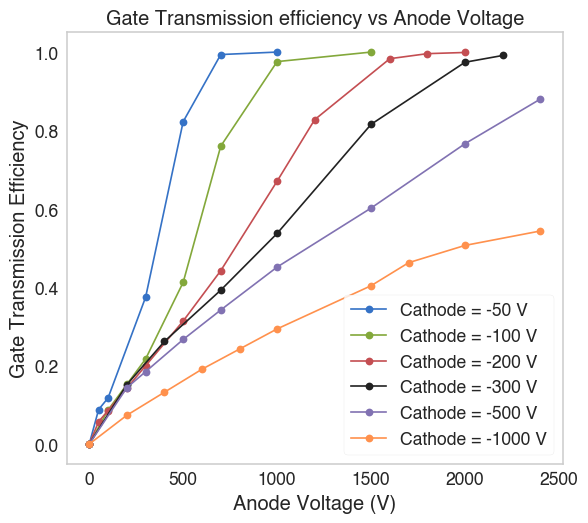

In [111]:
V0 = np.array([   0,   50,  100,  300,  500, 700, 1000])
I0 = np.array([-680, -620, -600, -425, -120, -3.5, 0.8])
T0 = 1 - I0 / I0[0]

V1 = np.array([   0,  100,  200,  300,  500,  700, 1000, 1500])
I1 = np.array([-690, -630, -585, -540, -405, -165,  -16,  0.8])
T1 = 1 - I1 / I1[0]

V2 = np.array([   0,  50,  100,  200,  300,  500,  700, 1000, 1200, 1600, 1800, 2000])
I2 = np.array([-700, -660, -640, -600, -560, -480, -390, -230, -120,  -11,   -2,  0.1])
T2 = 1 - I2 / I2[0]

V3 = np.array([   0,  200,  400,  700, 1000, 1500, 2000, 2200])
I3 = np.array([-725, -615, -535, -440, -335, -133,  -18, -5.5])
T3 = 1 - I3 / I3[0]

V4 = np.array([   0,  200,  300,  500,  700, 1000, 1500, 2000, 2400])
I4 = np.array([-730, -625, -595, -535, -480, -400,  -290, -170, -87])
T4 = 1 - I4 / I4[0]

V10 = np.array([   0,  200,  400,  600,  800, 1000, 1500, 1700, 2000, 2400])
I10 = np.array([-680, -630, -590, -550, -515, -480, -405, -365, -335, -310])
T10 = 1 - I10 / I10[0]

plt.plot(V0, T0, 'o-', label ='Cathode = -50 V')
plt.plot(V1, T1, 'o-', label='Cathode = -100 V')
plt.plot(V2, T2, 'o-', label='Cathode = -200 V')
plt.plot(V3, T3, 'ko-', label='Cathode = -300 V')
plt.plot(V4, T4, 'mo-', label='Cathode = -500 V')
plt.plot(V10, T10, 'yo-', label='Cathode = -1000 V')
plt.legend()
plt.gca().set(xlabel='Anode Voltage (V)', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs Anode Voltage')

In [2]:
700 / 0.8

875.0

[Text(0.5, 0, 'EL field / Drift field'),
 Text(0, 0.5, 'Gate Transmission Efficiency'),
 Text(0.5, 1.0, 'Gate Transmission efficiency vs EL/Drift field ratio')]

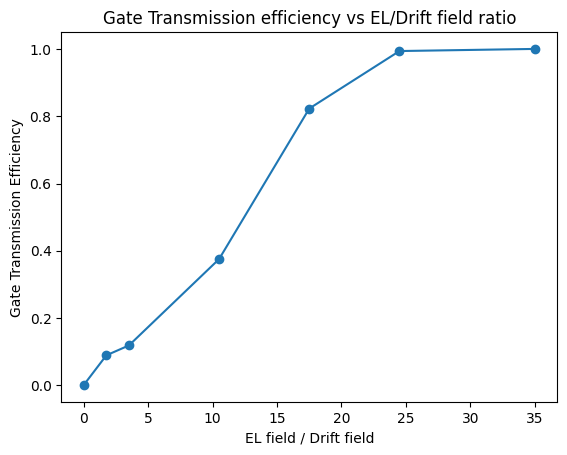

In [57]:
gap_el_cm = 0.8
gap_drift_cm = 1.4
V_gate = 0


V_cath0 = -50     # V
E_drift0 = ( V_gate - V_cath0) / gap_drift_cm
E_EL0 = (V0 - V_gate) / gap_el_cm
R_field = np.abs(E_EL0 / E_drift0)
plt.plot(R_field, T0, 'o-', label ='Cathode = -50 V')
plt.gca().set(xlabel='EL field / Drift field', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs EL/Drift field ratio')

[(0.0, 0.3), (0.0, 10.0)]

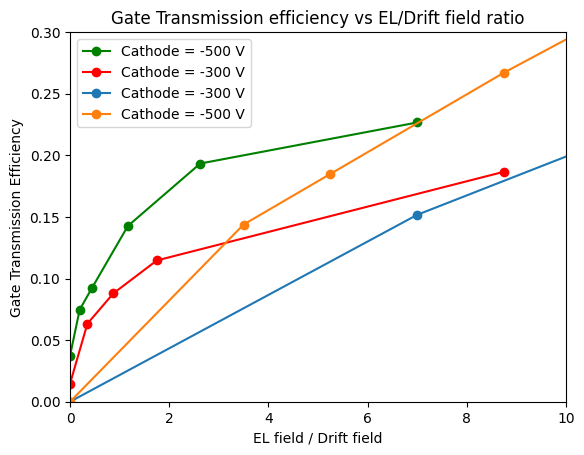

In [75]:
Vcath = np.array([-50, -100, -200, -300, -500])

# for i, (V, T) in enumerate([(V0, T0), (V1, T1), (V2, T2), (V3, T3), (V4, T4)]):
plt.plot(R_field5, T5, 'go-', label='Cathode = -500 V')
plt.plot(R_field3, T6, 'ro-', label='Cathode = -300 V')
for i, (V, T) in enumerate([(V3, T3), (V4, T4)]):

    R_field = compute_R_field(V, Vcath[i], V_gate, gap_drift_cm, gap_el_cm)
    plt.plot(R_field, T, 'o-', label=f'Cathode = {Vcath[i+3]} V')
plt.legend()
plt.gca().set(xlabel='EL field / Drift field', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs EL/Drift field ratio')
plt.gca().set(ylim=(0, 0.3), xlim=(0, 10))

In [77]:
300 * 0.74

222.0

[0.22666667 0.19333333 0.14266667 0.092      0.07466667 0.03733333]


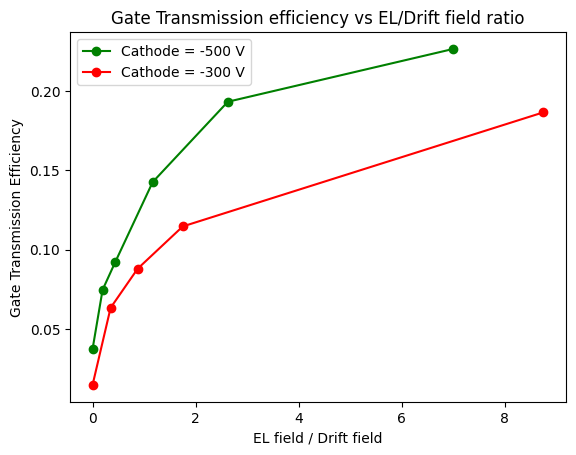

In [68]:
gap_el_cm = 0.8
gap_drift_cm = 1.4
V_anode = 0

Isat5 = -750
T5 = I5 / Isat5
R_field5 = compute_R_field(V_anode, -500, V5, gap_drift_cm, gap_el_cm)

Isat3 = -750
T6 = I3 / Isat3
R_field3 = compute_R_field(V_anode, -300, V3, gap_drift_cm, gap_el_cm)

plt.plot(R_field5, T5, 'go-', label='Cathode = -500 V')
plt.plot(R_field3, T6, 'ro-', label='Cathode = -300 V')
plt.legend()
plt.gca().set(xlabel='EL field / Drift field', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs EL/Drift field ratio')
print(T5)

# Transmission efficiency as a function of $E_{EL}/E_{drift}$

[Text(0.5, 0, 'R'),
 Text(0, 0.5, 'Gate Transmission Efficiency'),
 Text(0.5, 1.0, 'Gate Transmission efficiency vs Anode Voltage')]

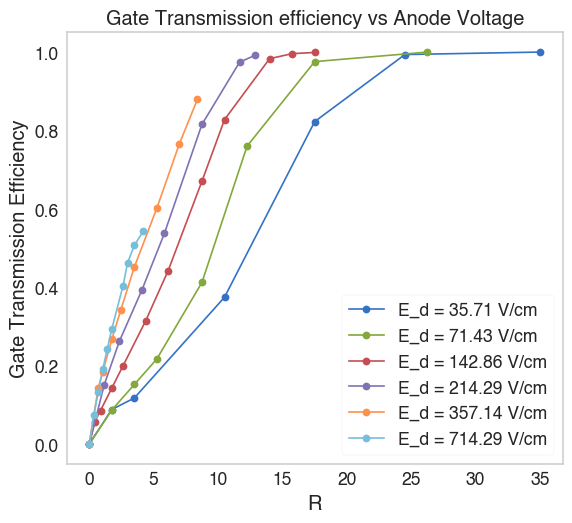

In [119]:
V_gate = 0
gap_drift_cm = 1.4 # cm
gap_el_cm = 0.8 # cm

V_cath0 = -50     # V
E_drift0 = ( V_gate - V_cath0) / gap_drift_cm
V0 = np.array([   0,   50,  100,  300,  500, 700, 1000])
I0 = np.array([-680, -620, -600, -425, -120, -3.5, 0.8])
T0 = 1 - I0 / I0[0]
R0 = compute_R_field(V0, V_cath0, V_gate, gap_drift_cm, gap_el_cm)

V_cath1 = -100     # V
E_drift1 = ( V_gate - V_cath1) / gap_drift_cm
V1 = np.array([   0,  100,  200,  300,  500,  700, 1000, 1500])
I1 = np.array([-690, -630, -585, -540, -405, -165,  -16,  0.8])
T1 = 1 - I1 / I1[0]
R1 = compute_R_field(V1, V_cath1, V_gate, gap_drift_cm, gap_el_cm)

V_cath2 = -200     # V
E_drift2 = ( V_gate - V_cath2) / gap_drift_cm
V2 = np.array([   0,  50,  100,  200,  300,  500,  700, 1000, 1200, 1600, 1800, 2000])
I2 = np.array([-700, -660, -640, -600, -560, -480, -390, -230, -120,  -11,   -2,  0.1])
T2 = 1 - I2 / I2[0]
R2 = compute_R_field(V2, V_cath2, V_gate, gap_drift_cm, gap_el_cm)

V_cath3 = -300     # V
E_drift3 = ( V_gate - V_cath3) / gap_drift_cm
V3 = np.array([   0,  200,  400,  700, 1000, 1500, 2000, 2200])
I3 = np.array([-725, -615, -535, -440, -335, -133,  -18, -5.5])
T3 = 1 - I3 / I3[0]
R3 = compute_R_field(V3, V_cath3, V_gate, gap_drift_cm, gap_el_cm)

V_cath4 = -500     # V
E_drift4 = ( V_gate - V_cath4) / gap_drift_cm
V4 = np.array([   0,  200,  300,  500,  700, 1000, 1500, 2000, 2400])
I4 = np.array([-730, -625, -595, -535, -480, -400,  -290, -170, -87])
T4 = 1 - I4 / I4[0]
R4 = compute_R_field(V4, V_cath4, V_gate, gap_drift_cm, gap_el_cm)

V_cath10 = -1000     # V
E_drift10 = ( V_gate - V_cath10) / gap_drift_cm
V10 = np.array([   0,  200,  400,  600,  800, 1000, 1500, 1700, 2000, 2400])
I10 = np.array([-680, -630, -590, -550, -515, -480, -405, -365, -335, -310])
T10 = 1 - I10 / I10[0]
R10 = compute_R_field(V10, V_cath10, V_gate, gap_drift_cm, gap_el_cm)

plt.plot(R0, T0, 'o-', label ='E_d = {:.2f} V/cm'.format(E_drift0))
plt.plot(R1, T1, 'o-', label='E_d = {:.2f} V/cm'.format(E_drift1))
plt.plot(R2, T2, 'o-', label='E_d = {:.2f} V/cm'.format(E_drift2))
plt.plot(R3, T3, 'o-', label='E_d = {:.2f} V/cm'.format(E_drift3))
plt.plot(R4, T4, 'o-', label='E_d = {:.2f} V/cm'.format(E_drift4))
plt.plot(R10, T10, 'o-', label='E_d = {:.2f} V/cm'.format(E_drift10))
plt.legend()
plt.gca().set(xlabel='R', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs Anode Voltage')

In [123]:
1000 / 0.8

1250.0

In [120]:
from scipy.optimize import curve_fit

# 1. Define the sigmoid (logistic) function
def sigmoid(x, k, x0):
    # We fix the maximum value (L) to 1.0 for physical transparency
    return 1 / (1 + np.exp(-k * (x - x0)))


def fit_sigmoid(R_data, T_data):
# p0 is an initial guess: [steepness, midpoint]
    popt, pcov = curve_fit(sigmoid, R_data, T_data, p0=[0.5, 7.0])

    # 4. Generate the fit curve for plotting
    R_fit = np.linspace(0, 35, 100)
    T_fit = sigmoid(R_fit, *popt)
    return popt, R_fit, T_fit

Fitted parameters: k = 0.27, x0 = 12.05
Fitted parameters: k = 0.35, x0 = 9.23
Fitted parameters: k = 0.40, x0 = 6.61
Fitted parameters: k = 0.45, x0 = 5.22
Fitted parameters: k = 0.48, x0 = 4.19
Fitted parameters: k = 0.64, x0 = 3.46


[Text(0.5, 0, 'R'),
 Text(0, 0.5, 'Gate Transmission Efficiency'),
 Text(0.5, 1.0, 'Gate Transmission efficiency vs Anode Voltage')]

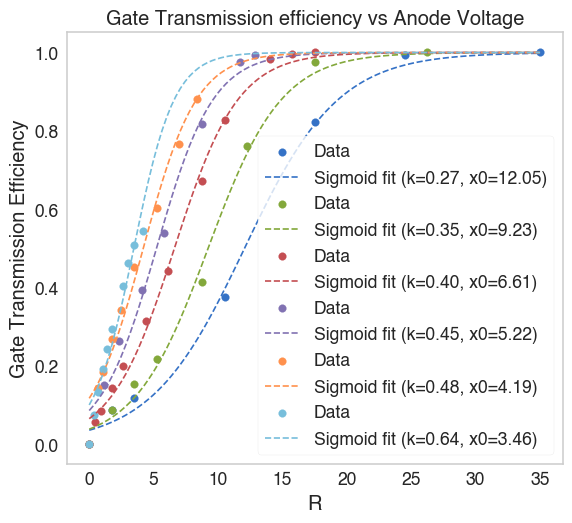

In [121]:
for R, T in [(R0, T0), (R1, T1), (R2, T2), (R3, T3), (R4, T4), (R10, T10)]:
    popt, R_fit, T_fit = fit_sigmoid(R, T)
    plt.scatter(R, T, label='Data')
    plt.plot(R_fit, T_fit, '--', label=f'Sigmoid fit (k={popt[0]:.2f}, x0={popt[1]:.2f})')
    print(f"Fitted parameters: k = {popt[0]:.2f}, x0 = {popt[1]:.2f}")
plt.legend()
plt.gca().set(xlabel='R', ylabel='Gate Transmission Efficiency', title='Gate Transmission efficiency vs Anode Voltage')

# Extrapolate for E_EL = 3.375 kV/cm

In [122]:
1000/0.8

1250.0

In [127]:
np.array([50, 100, 200, 300, 500, 1000]) / 1.4

array([ 35.71428571,  71.42857143, 142.85714286, 214.28571429,
       357.14285714, 714.28571429])

In [129]:
from scipy.interpolate import interp1d

In [130]:
ed_anchors = np.array([35.71, 71.43, 142.86, 214.29, 357.14, 714.29])
k_anchors  = np.array([0.27, 0.35, 0.40, 0.45, 0.48, 0.64])
x0_anchors = np.array([12.05, 9.23, 6.61, 5.22, 4.19, 3.46])

# 2. Create functions that describe how the grid parameters change with Drift Field
# We use linear interpolation for the parameters themselves
get_k_param = interp1d(ed_anchors, k_anchors, kind='linear', fill_value="extrapolate")
get_x0_param = interp1d(ed_anchors, x0_anchors, kind='linear', fill_value="extrapolate")

def get_transmission_2d(E_drift, R):
    """
    Physically-motivated 2D interpolation.
    First finds the sigmoid shape for the drift field, then applies the ratio R.
    """
    # Step A: Interpolate the shape of the sigmoid for this specific E_drift
    k_current = get_k_param(E_drift)
    x0_current = get_x0_param(E_drift)
    
    # Step B: Calculate T using the reconstructed sigmoid
    t = 1 / (1 + np.exp(-k_current * (R - x0_current)))
    
    return np.clip(t, 0, 1)

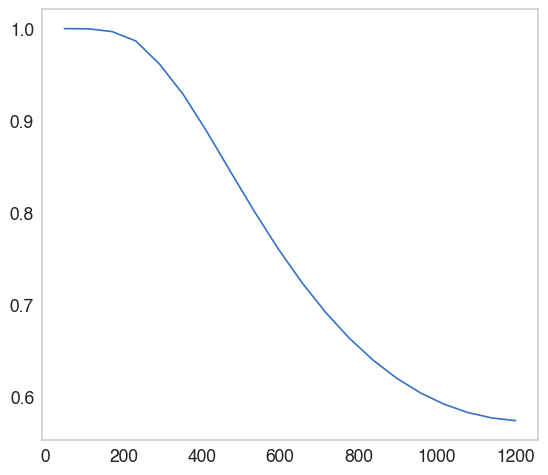

In [145]:
E_EL = 3375
E_drift_vals = np.linspace(50, 1200, 20)    # V/cm
R_vals = E_EL / E_drift_vals
T_2D = get_transmission_2d(E_drift_vals, R_vals)
plt.plot(E_drift_vals, T_2D, 'b-', label='Physics-informed 2D Interpolation')

In [150]:
# E_drift_vals = [  50.        ,  110.52631579,  171.05263158,  231.57894737,
#         292.10526316,  352.63157895,  413.15789474,  473.68421053,
#         534.21052632,  594.73684211,  655.26315789,  715.78947368,
#         776.31578947,  836.84210526,  897.36842105,  957.89473684,
#        1018.42105263, 1078.94736842, 1139.47368421, 1200.        ]

# T_2D = [0.99999996, 0.99981244, 0.99678758, 0.98660979, 0.96141301,
#        0.92838636, 0.88770413, 0.84406857, 0.80099599, 0.76052024,
#        0.72377313, 0.69126794, 0.66313436, 0.63928431, 0.6195191 ,
#        0.60359465, 0.59125885, 0.58227151, 0.57641349, 0.57348948]

# ETL pipeline

In [56]:
path = Path('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency')

files = sorted(list(path.glob('*.txt')))
file0 = files[0]
data = pd.read_csv(file0, sep='\t', skiprows=0)
data

,Timestamp(ISO8601),Time_s,Current_A
0,02-Feb-2026 15:14:46,2.189,4.701580e-10
1,02-Feb-2026 15:14:47,2.908,4.767493e-10
2,02-Feb-2026 15:14:47,3.658,4.734194e-10
3,02-Feb-2026 15:14:48,4.404,4.887553e-10
4,02-Feb-2026 15:14:49,5.138,4.959468e-10
...,...,...,...
823,02-Feb-2026 15:24:51,606.970,4.779966e-10
824,02-Feb-2026 15:24:51,607.704,4.856464e-10
825,02-Feb-2026 15:24:52,608.460,4.814767e-10
826,02-Feb-2026 15:24:53,609.188,4.873552e-10


[Text(0.5, 0, 'Time (s)'),
 Text(0, 0.5, 'Current (A)'),
 Text(0.5, 1.0, 'Current vs Time')]

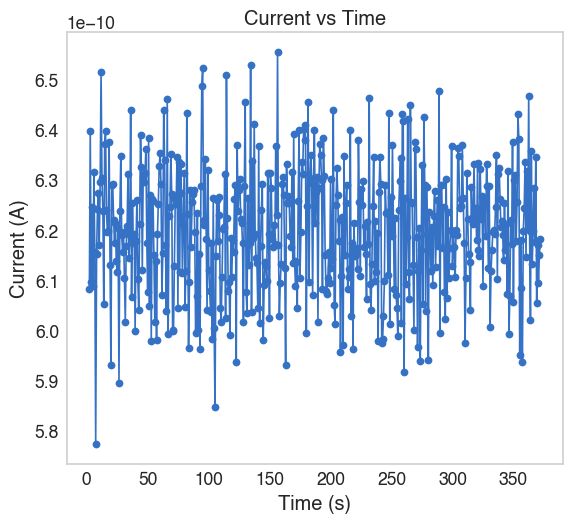

In [19]:
plt.plot(data['Time_s'], data['Current_A'], 'o-')
plt.gca().set(xlabel='Time (s)', ylabel='Current (A)', title='Current vs Time')

(np.float64(6.198914833663367e-10), np.float64(1.2761160337844485e-11))

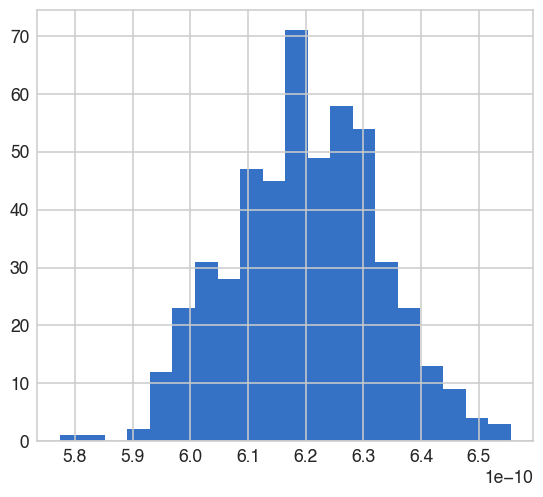

In [24]:
data['Current_A'].hist(bins=20)
data['Current_A'].mean(), data['Current_A'].std()

In [29]:
def drop_outliers(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    outliers = data[np.abs(data[column] - mean) > threshold * std]
    return data[~data.index.isin(outliers.index)]
data_drop = drop_outliers(data, 'Current_A')

In [32]:
def get_mean_current_pA(current_series):
    mean_A = current_series.mean()
    std_A = current_series.std()
    mean_pA = mean_A * 1e12
    std_pA = std_A * 1e12

    return mean_pA, std_pA
mean_current, std_current = get_mean_current_pA(data_drop['Current_A'])
print(f"Mean current: {mean_current:.1f} pA, Std: {std_current:.1f} pA")

Mean current: 620.0 pA, Std: 12.6 pA


In [35]:
files

[PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P10_CurrentLog_2026-02-02_151442.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P11_CurrentLog_2026-02-02_152511.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P12_CurrentLog_2026-02-02_155546.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P13_CurrentLog_2026-02-02_160426.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P14_CurrentLog_2026-02-02_161137.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P1_CurrentLog_2026-02-02_122440.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P2_CurrentLog_2026-02-02_123851.txt'),
 PosixPath('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN0_P3_CurrentLog_2026-02-02_125847.tx

In [50]:
def extract_collection_curve(file_path, run_id: str):
    files = sorted(list(Path(file_path).glob(f'{run_id}*.txt')))
    if not files:
        print(f"No files found for run_id: {run_id}")
        return None
    
    current_values_pA = []
    current_errors_pA = []
    for file in files:
        data = pd.read_csv(file, sep='\t', skiprows=0)
        data_drop = drop_outliers(data, 'Current_A')
        mean_current, std_current = get_mean_current_pA(data_drop['Current_A'])
        # print(f"File: {file.name}, Mean current: {mean_current:.1f} pA, Std: {std_current:.1f} pA")
        current_values_pA.append(mean_current)
        current_errors_pA.append(std_current)
    plt.errorbar(range(len(current_values_pA)), current_values_pA, yerr=current_errors_pA, 
                 marker='o', capsize=5, capthick=1, label=run_id.replace('_', ''))
    plt.gca().set(xlabel='Measurement (ID)', ylabel='Current (pA)', title='Current vs Time')
    plt.legend()

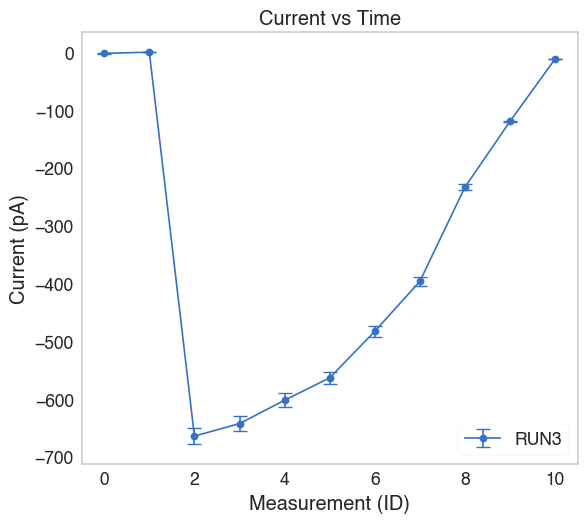

In [53]:
extract_collection_curve('/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency', 'RUN3_')

## Inspect RUN19:

In [177]:
file20 = '/Users/pabloherrero/sabat/RaTagging/scope_data/collection_efficiency/RUN19_P9_CurrentLog_2026-02-12_123040.txt'
data = pd.read_csv(file20, sep='\t', skiprows=0)
data

,Timestamp(ISO8601),Time_s,Current_A
0,12-Feb-2026 12:30:44,2.196,-3.786515e-10
1,12-Feb-2026 12:30:45,2.928,-3.804480e-10
2,12-Feb-2026 12:30:45,3.670,-3.771181e-10
3,12-Feb-2026 12:30:46,4.395,-3.780408e-10
4,12-Feb-2026 12:30:47,5.126,-3.877224e-10
...,...,...,...
427,12-Feb-2026 12:35:58,316.298,-3.766876e-10
428,12-Feb-2026 12:35:59,317.032,-3.717566e-10
429,12-Feb-2026 12:36:00,317.769,-3.750130e-10
430,12-Feb-2026 12:36:00,318.497,-3.703202e-10


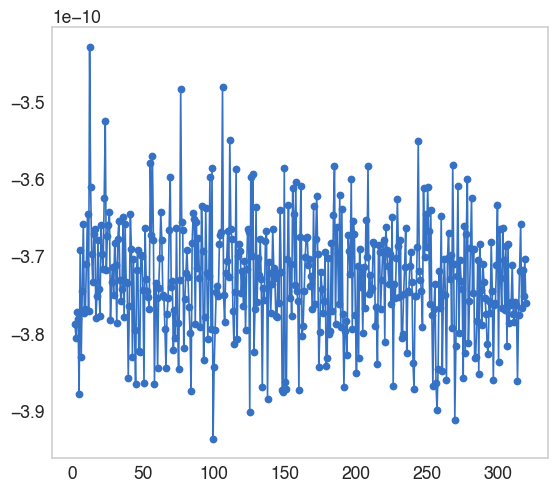

In [178]:
plt.plot(data['Time_s'], data['Current_A'], 'o-')

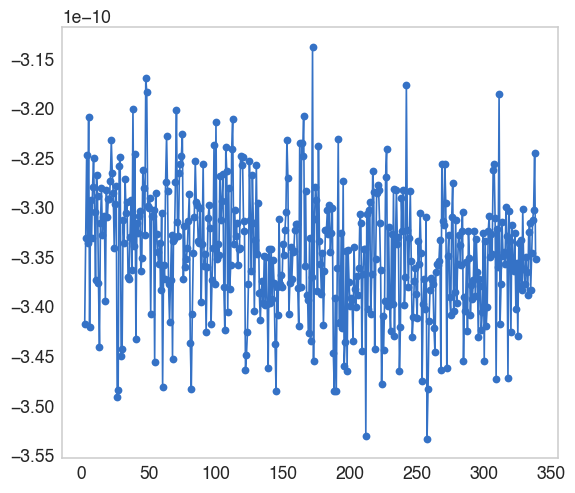

In [ ]:
plt.plot(data['Time_s'], data['Current_A'], 'o-')

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,  27., 146., 187.,  39.,   4.]),
 array([-1.02072300e-11, -9.95369815e-12, -9.70016630e-12, -9.44663445e-12,
        -9.19310260e-12, -8.93957075e-12, -8.68603890e-12, -8.43250705e-12,
        -8.17897520e-12, -7.92544335e-12, -7.67191150e-12, -7.41837965e-12,
        -7.16484780e-12, -6.91131595e-12, -6.65778410e-12, -6.40425225e-12,
        -6.15072040e-12, -5.89718855e-12, -5.64365670e-12, -5.39012485e-12,
        -5.13659300e-12]),
 <BarContainer object of 20 artists>)

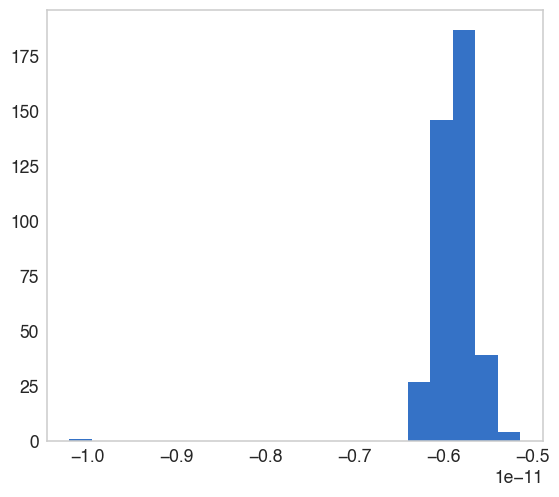

In [67]:
plt.hist(data['Current_A'], bins=20)

In [72]:
data_drop = drop_outliers(data, 'Current_A', threshold=3)
mean_current, std_current = get_mean_current_pA(data_drop['Current_A'])
print(f"Mean current: {mean_current:.1f} pA, Std: {std_current:.1f} pA")

Mean current: -5.9 pA, Std: 0.2 pA


(array([ 5.,  4., 12., 15., 20., 31., 52., 48., 58., 51., 41., 29., 19.,
         9.,  4.,  1.,  1.,  1.,  0.,  2.]),
 array([-6.36484000e-12, -6.30342765e-12, -6.24201530e-12, -6.18060295e-12,
        -6.11919060e-12, -6.05777825e-12, -5.99636590e-12, -5.93495355e-12,
        -5.87354120e-12, -5.81212885e-12, -5.75071650e-12, -5.68930415e-12,
        -5.62789180e-12, -5.56647945e-12, -5.50506710e-12, -5.44365475e-12,
        -5.38224240e-12, -5.32083005e-12, -5.25941770e-12, -5.19800535e-12,
        -5.13659300e-12]),
 <BarContainer object of 20 artists>)

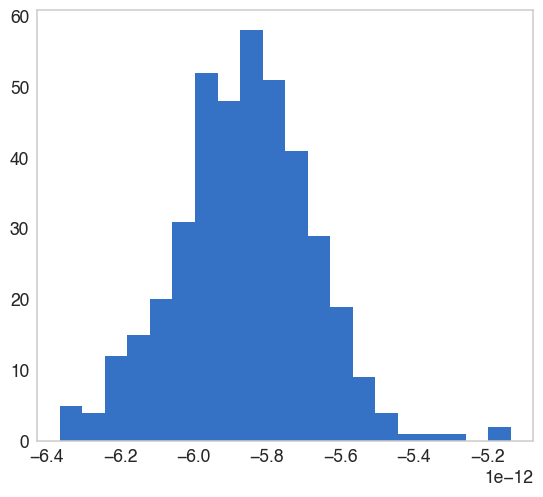

In [71]:
plt.hist(data_drop['Current_A'], bins=20)